# ParetoServe Sprint 1 Analysis

This notebook reads the benchmark artifacts produced by `experiments/run_benchmarks.py` and recreates the main summary tables and plots used in the report.

## Setup

Run from the project root with the local environment activated:

```bash
. .venv/bin/activate
jupyter notebook notebooks/paretoserve_analysis.ipynb
```

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

#project_root = Path.cwd()
# project_root = ".."
# bench_dir = project_root / 'artifacts' / 'benchmarks'
bench_dir = "../artifacts/benchmarks"
plots_dir = '../artifacts/benchmarksplots'

sim = pd.read_csv('../artifacts/benchmarks/simulator_results.csv')
real = pd.read_csv('../artifacts/benchmarks/real_results.csv')

print('Benchmark directory:', bench_dir)
print('Simulator rows:', len(sim))
print('Real rows:', len(real))

Benchmark directory: ../artifacts/benchmarks
Simulator rows: 8
Real rows: 30


In [2]:
sim.sort_values(['workload', 'policy'])

,benchmark,workload,policy,episodes,avg_reward,avg_k,avg_acceptance_rate,steps
4,simulator,bursty_high_load,adaptive_rl,40.0,-5.757133,2.532812,0.346354,NaN
5,simulator,bursty_high_load,fixed_k_1,NaN,-3.702731,1.000000,0.542188,640.0
6,simulator,bursty_high_load,fixed_k_3,NaN,-6.492720,3.000000,0.244271,640.0
7,simulator,bursty_high_load,fixed_k_5,NaN,-9.728852,5.000000,0.145938,640.0
0,simulator,steady_low_load,adaptive_rl,40.0,-1.139329,2.395313,0.546536,NaN
1,simulator,steady_low_load,fixed_k_1,NaN,0.257346,1.000000,0.776563,640.0
2,simulator,steady_low_load,fixed_k_3,NaN,-1.555158,3.000000,0.452604,640.0
3,simulator,steady_low_load,fixed_k_5,NaN,-5.916230,5.000000,0.225000,640.0


In [3]:
real.groupby(['policy', 'workload'])[['avg_k', 'avg_reward', 'avg_acceptance_rate', 'avg_step_time_s', 'generated_length_delta']].mean().round(4)

avg_k  avg_reward  \
policy                workload                               
adaptive_rl           bursty_high_load  3.3333      9.5411   
                      steady_low_load   3.2222     11.1178   
autoregressive_cached bursty_high_load  0.0000      0.0000   
                      steady_low_load   0.0000      0.0000   
fixed_k_1             bursty_high_load  1.0000     16.2376   
                      steady_low_load   1.0000     16.6009   
fixed_k_3             bursty_high_load  3.0000      9.5150   
                      steady_low_load   3.0000     11.2297   
fixed_k_5             bursty_high_load  5.0000      6.8941   
                      steady_low_load   5.0000      8.0057   

                                        avg_acceptance_rate  avg_step_time_s  \
policy                workload                                                 
adaptive_rl           bursty_high_load                  0.0           0.1118   
                      steady_low_load                   0.0           0.1145   
autoregressive_cached bursty_high_load                  0.0           0.0545   
                      steady_low_load                   0.0           0.0690   
fixed_k_1             bursty_high_load                  0.0           0.0790   
                      steady_low_load                   0.0           0.0814   
fixed_k_3             bursty_high_load                  0.0           0.1119   
                      steady_low_load                   0.0           0.1098   
fixed_k_5             bursty_high_load                  0.0           0.1306   
                      steady_low_load                   0.0           0.1331   

                                        generated_length_delta  
policy                workload                                  
adaptive_rl           bursty_high_load                     3.0  
                      steady_low_load                      3.0  
autoregressive_cached bursty_high_load                     3.0  
                      steady_low_load                      3.0  
fixed_k_1             bursty_high_load                     3.0  
                      steady_low_load                      3.0  
fixed_k_3             bursty_high_load                     3.0  
                      steady_low_load                      3.0  
fixed_k_5             bursty_high_load                     3.0  
                      steady_low_load                      3.0

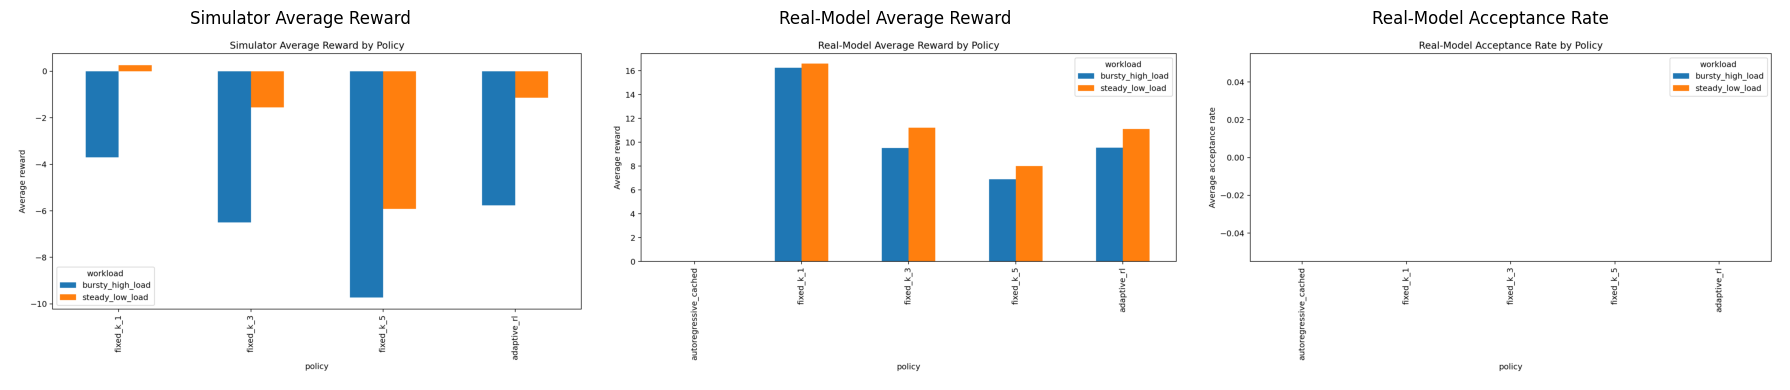

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, image_name, title in zip(
    axes,
    ['simulator_avg_reward.png', 'real_avg_reward.png', 'real_acceptance_rate.png'],
    ['Simulator Average Reward', 'Real-Model Average Reward', 'Real-Model Acceptance Rate'],
):
    img = plt.imread("../artifacts/benchmarks/plots/" + image_name)
    ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()

In [5]:
real[['prompt', 'policy', 'workload', 'avg_reward', 'avg_acceptance_rate', 'generated_text']].sort_values(['prompt', 'workload', 'policy'])

,prompt,policy,workload,avg_reward,avg_acceptance_rate,generated_text
19,Adaptive inference control,adaptive_rl,bursty_high_load,11.539514,0.0,Adaptive inference control.\n\n
15,Adaptive inference control,autoregressive_cached,bursty_high_load,0.000000,0.0,Adaptive inference control.\n\n
16,Adaptive inference control,fixed_k_1,bursty_high_load,16.301504,0.0,Adaptive inference control.\n\n
17,Adaptive inference control,fixed_k_3,bursty_high_load,11.581902,0.0,Adaptive inference control.\n\n
18,Adaptive inference control,fixed_k_5,bursty_high_load,7.116276,0.0,Adaptive inference control.\n\n
4,Adaptive inference control,adaptive_rl,steady_low_load,13.207765,0.0,Adaptive inference control.\n\n
0,Adaptive inference control,autoregressive_cached,steady_low_load,0.000000,0.0,Adaptive inference control.\n\n
1,Adaptive inference control,fixed_k_1,steady_low_load,16.139764,0.0,Adaptive inference control.\n\n
2,Adaptive inference control,fixed_k_3,steady_low_load,14.138273,0.0,Adaptive inference control.\n\n
3,Adaptive inference control,fixed_k_5,steady_low_load,7.561539,0.0,Adaptive inference control.\n\n
